<a href="https://colab.research.google.com/github/ekarau/Deep-Learning-with-Python-Project/blob/main/The_Impact_of_Activation_Functions_on_Training_Dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 511kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.15MB/s]


In [ ]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [ ]:
class Model(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            activation,
            nn.Linear(128, 128),
            activation,
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def train_model(activation_fn):
    model = Model(activation_fn)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    losses = []

    for epoch in range(10):
        total_loss = 0

        for x, y in train_loader:
            optimizer.zero_grad()

            pred = model(x)
            loss = loss_fn(pred, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        losses.append(total_loss)
        print(f"Epoch {epoch}: {total_loss}")

    return losses

In [ ]:
relu_loss = train_model(nn.ReLU())
sigmoid_loss = train_model(nn.Sigmoid())
tanh_loss = train_model(nn.Tanh())
leaky_loss = train_model(nn.LeakyReLU())

Epoch 0: 296.22531811892986
Epoch 1: 118.92100324481726
Epoch 2: 81.35408050986007
Epoch 3: 61.91775501635857
Epoch 4: 48.30053714802489
Epoch 5: 38.58453578571789
Epoch 6: 31.043506695714314
Epoch 7: 26.736447647883324
Epoch 8: 21.12116403566324
Epoch 9: 18.79470263166877
Epoch 0: 574.1697314828634
Epoch 1: 192.32440213114023
Epoch 2: 137.23512426763773
Epoch 3: 104.83987739495933
Epoch 4: 83.0457507353276
Epoch 5: 67.75342575926334
Epoch 6: 55.39617505623028
Epoch 7: 46.030031201196834
Epoch 8: 38.52038244577125
Epoch 9: 31.29988657037029
Epoch 0: 286.6327621899545
Epoch 1: 125.47436312399805
Epoch 2: 85.05003282567486
Epoch 3: 62.6844268348068
Epoch 4: 46.39175511908252
Epoch 5: 36.071090101148
Epoch 6: 28.611830554698827
Epoch 7: 22.198359929258004
Epoch 8: 17.506796883040806
Epoch 9: 15.262278769747354
Epoch 0: 294.04076877981424
Epoch 1: 120.03748582769185
Epoch 2: 80.92676104884595
Epoch 3: 59.18203873257153
Epoch 4: 46.77305447612889
Epoch 5: 38.297825459740125
Epoch 6: 30.4660

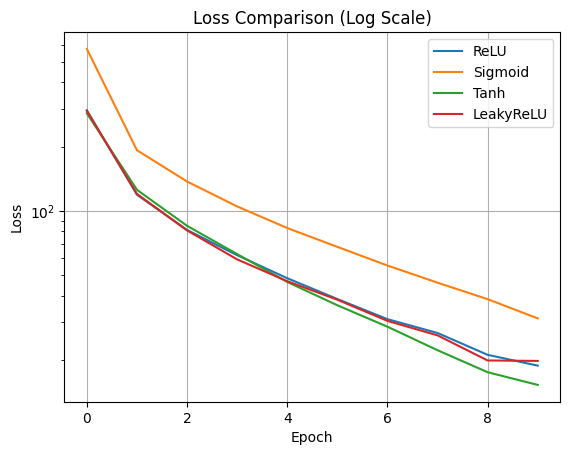

In [ ]:
plt.plot(relu_loss, label="ReLU")
plt.plot(sigmoid_loss, label="Sigmoid")
plt.plot(tanh_loss, label="Tanh")
plt.plot(leaky_loss, label="LeakyReLU")

plt.yscale("log")

plt.legend()
plt.title("Loss Comparison (Log Scale)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()